In [1]:
import os
# Get the current working directory
current_dir = os.getcwd()
# Set the data directory to the parent directory of the current working directory
wdir = os.path.dirname(current_dir)
# Change the current working directory to the parent directory
os.chdir(wdir)

In [2]:
import sys
sys.path.append('src')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams


In [3]:
# Set the font globally
rcParams['font.family'] = 'Arial'
rcParams['font.size'] = 9
rcParams['axes.titlesize'] = 9
rcParams['axes.labelsize'] = 9
rcParams['xtick.labelsize'] = 9
rcParams['ytick.labelsize'] = 9
rcParams['legend.fontsize'] = 9

In [4]:
# define plotwidth
def cm2inch(x): return float(x)/2.54
plotwidth    = cm2inch(8.90)

In [12]:
# Parameters
p_cd = 0.0004
t_s = 2
bf_mut = 1e-3  # 10^-3
max_slopes_null = np.loadtxt(f"data/Supplementary_Fig_7/max_slope_null_bf_m_{bf_mut}_t2_{t_s}.txt")
accumulated_mutations_null = np.loadtxt(f"data/Supplementary_Fig_7/accumulated_mutations_null.txt")


# Load CSV Read CSVs
df1 = pd.read_csv("data/Supplementary_Fig_7/sensitivity_results_lognormal_1.csv")
df2 = pd.read_csv("data/Supplementary_Fig_7/sensitivity_results_lognormal_2.csv")
df3 = pd.read_csv("data/Supplementary_Fig_7/sensitivity_results_lognormal_3.csv")
df4 = pd.read_csv("data/Supplementary_Fig_7/sensitivity_results_lognormal_4.csv")



max_slopes_null = np.max(max_slopes_null)
median_accumulated_mutations_null = np.median(accumulated_mutations_null)

# Concatenate vertically
df_all = pd.concat([df1, df2, df3, df4], ignore_index=True)


df_all["delta_slope"] = df_all["mean_max_slope_jump"] - df_all["mean_max_slope_nojump"]
df_all["delta_mut"]  = df_all["median_final_mut_jump"] - df_all["median_final_mut_nojump"]

df_all["delta_slope_with_null"] = df_all["mean_max_slope_jump"] - max_slopes_null
df_all["delta_mut_with_null"]  = df_all["median_final_mut_jump"] - median_accumulated_mutations_null

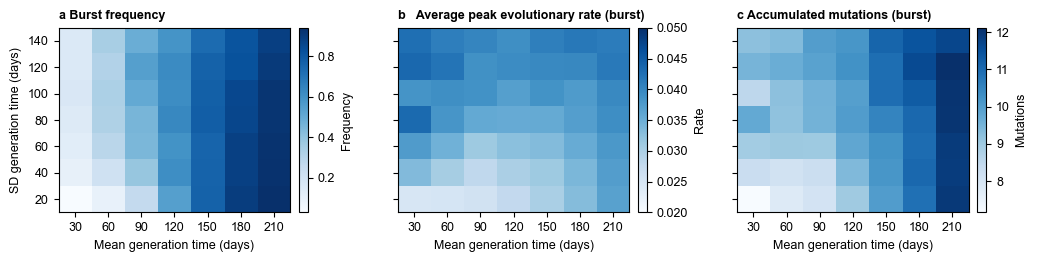

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# --- Data preparation ---

mean_days = np.array([30, 60, 90, 120, 150, 180, 210])
sd_days   = np.array([20, 40, 60, 80, 100, 120, 140])

# Ensure pivot tables are in the correct order
H1 = df_all.pivot(index="sd", columns="mean", values="burst_freq").loc[sd_days, mean_days].values
H2 = df_all.pivot(index="sd", columns="mean", values="mean_max_slope_jump").loc[sd_days, mean_days].values
H3 = df_all.pivot(index="sd", columns="mean", values="median_final_mut_jump").loc[sd_days, mean_days].values

# --- FIGURE ---
fig = plt.figure(figsize=(3.0 * plotwidth, 0.7 * plotwidth))

for i, (data, title, label) in enumerate([
    (H1, "a Burst frequency", "Frequency"),
    (H2, "b   Average peak evolutionary rate (burst)", "Rate"),
    (H3, "c Accumulated mutations (burst)", "Mutations")
]):

    ax = fig.add_subplot(1, 3, i+1)

    # --- Force color scale for H2 only ---
    if i == 1:   # H2 panel
        vmin, vmax = 0.02, 0.05
    else:
        vmin, vmax = data.min(), data.max()

    heatmap = ax.imshow(
        data,
        aspect='auto',
        origin='lower',
        cmap='Blues',
        vmin=vmin,
        vmax=vmax
    )

    # -----------------------------
    # USE CUSTOM AXIS LABELS
    # -----------------------------
    ax.set_xticks(np.arange(len(mean_days)))
    ax.set_xticklabels(mean_days)

    ax.set_yticks(np.arange(len(sd_days)))
    ax.set_yticklabels(sd_days)
    # -----------------------------

    # Colorbar
    cbar = plt.colorbar(heatmap, ax=ax, pad=0.03)
    cbar.set_label(label, color='black')

    for tick_label in cbar.ax.yaxis.get_ticklabels():
        tick_label.set_fontname('Arial')

    ax.set_title(title, loc='left', weight='bold')

    ax.set_xlabel("Mean generation time (days)")

    if i == 0:
        ax.set_ylabel("SD generation time (days)")
    else:
        ax.set_ylabel("")
        ax.set_yticklabels([])

plt.tight_layout()
plt.subplots_adjust(bottom=0.12, wspace=0.2)
plt.show()
plt.show()